<a href="https://colab.research.google.com/github/MGentieu/dl_project/blob/main/starters/cv-project-starter/cv-project/notebooks/CV_Caltech-101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connexion à github

Pour github : à exécuter dans le terminal de colab

```bash
git clone https://github.com/MGentieu/dl_project.git

# CV Starter — Colab/Kaggle Quickstart

> Author : Badr TAJINI

**Academic year:** 2025–2026  
**School:** ECE  
**Course:** Machine Learning & Deep Learning 2

---


Welcome! This notebook is intentionally beginner-friendly. Follow the steps exactly and you will confirm that the starter project works on a free GPU runtime.

### Before you run anything
1. **Open the notebook in Google Colab or Kaggle.**
2. **Change the hardware accelerator to GPU (T4 preferred).**
   * Colab: `Runtime` → `Change runtime type` → Hardware accelerator `GPU` → Save.
   * Kaggle: `Settings` (gear icon) → Turn on `Accelerator` → Choose `T4 x1`.
3. Once the GPU is enabled, run the cells **from top to bottom**. Every code cell has comments explaining what it does.

The notebook will: (a) check that a GPU is available, (b) install dependencies, (c) run a quick smoke test that loads CIFAR-10 and performs one training step, and (d) show you how to launch the full training/evaluation commands when you are ready for longer experiments.

## 0. Project files

- Option A: `git clone <your_repo_url> cv-project`
- Option B: Upload the `cv-project` folder via the left sidebar (ensure the root is `/content/cv-project`).

Run the cell below afterwards; it will raise a helpful error if the folder is missing.

### Quick checklist before running code

- **Colab:** Go to `Runtime → Change runtime type`, pick `GPU`, and click **Save**.
- **Kaggle:** Open the gear icon in the top-right, enable **Accelerator**, and choose `T4 x1`.
- Wait for the runtime to restart (Colab shows `Connected` again).
- Then run every cell in order. If you see an error, stop, read the message, and re-run the cell after fixing the issue.

Once the smoke test succeeds you can run the full training and evaluation commands shown at the end of the notebook.

### How to run a cell
- Click the little ▶️ button on the left of a cell, or press **Shift + Enter** (Colab) / **Ctrl + Enter** (Kaggle).
- Wait for the cell to finish (a number like `[1]` appears once it is done).
- If a cell shows an error, read the message, fix the issue, and re-run that same cell before moving forward.


### Step 0 — Confirm the GPU is ready
Run the next cell. You should see a table with GPU details (name + memory).
If you get the message `nvidia-smi unavailable`, the runtime is still on CPU—go back to the checklist above and switch it to GPU, then rerun the cell.


In [1]:
!nvidia-smi || echo "nvidia-smi unavailable (CPU runtime)"

Mon Dec  1 14:20:20 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

On vérifie ensuite qu'on est bien en train d'utiliser un GPU. Si c'est le cas, la cellule en-dessous affiche **cuda** :

In [2]:
# Install required libraries
!pip -q install torch torchvision torchmetrics==1.4.0 matplotlib tqdm ultralytics datasets scikit-learn

# Set seeds for reproducibility
import torch, random, numpy as np
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## Importation des biliothèques

Pas besoin nécessairement d'installer des modules indiqués dans requirements.txt => Les bibliothèques existent déjà par défaut dans Colab.

In [3]:
import os
import sys
from pathlib import Path
import yaml
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image, Markdown
import json
import pandas as pd
import seaborn as sns

### Step 1 — Point the notebook at the project folder
This cell makes sure Colab/Kaggle is looking at the `cv-project` directory.
If it raises a `FileNotFoundError`, you likely uploaded the folder to a different place. Use the file browser on the left to confirm the path, fix it, and rerun the cell.


In [4]:
# The user has provided the explicit path to the project root.
PROJECT_ROOT = Path("/content/dl_project/starters/cv-project-starter/cv-project")

print(f"Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT")

# Validate structure
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(f"Missing src/ directory at {PROJECT_ROOT}")

# Setup Python path
os.chdir(PROJECT_ROOT)
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")


Environment: Colab/Kaggle (remote server), using provided PROJECT_ROOT
Project root: /content/dl_project/starters/cv-project-starter/cv-project
Working directory: /content/dl_project/starters/cv-project-starter/cv-project


In [5]:
# Simulation du contenu du fichier YAML (si tu l'as localement, utilise open('cv_caltech101.yaml'))
yaml_content = open('configs/cv_caltech101.yaml')

config = yaml.safe_load(yaml_content)

# Création du dossier de sortie
os.makedirs(config['output_dir'], exist_ok=True)

# Configuration du Device (GPU / MPS pour Mac / CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Utilisation du device : {device}")

Utilisation du device : cuda


In [6]:
data_transforms = transforms.Compose([
    transforms.Resize((config['data']['img_size'], config['data']['img_size'])),
    transforms.Lambda(lambda x: x.convert("RGB")),  # <--- Fix pour les images N/B
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.Caltech101(root=config['data']['root'], download=True, transform=data_transforms)
val_size = int(len(full_dataset) * config['data']['val_split'])
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=config['data']['batch_size'], shuffle=True, num_workers=2),
    'val': DataLoader(val_dataset, batch_size=config['data']['batch_size'], shuffle=False, num_workers=2)
}
dataset_sizes = {'train': train_size, 'val': val_size}
num_classes = len(full_dataset.categories)

print(f"Classes: {num_classes}")
print(f"Images d'entraînement: {train_size}, Images de validation: {val_size}")

# 3. FONCTION D'ENTRAÎNEMENT GÉNÉRIQUE
def run_training_phase(model, optimizer, scheduler, num_epochs, phase_name):
    print(f"\n=== Démarrage {phase_name} ({num_epochs} époques) ===")
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history_acc = []

    for epoch in range(num_epochs):
        print(f'Époque {epoch+1}/{num_epochs}')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()


            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'val':
                history_acc.append(epoch_acc.item())
                print(f'{phase} Acc: {epoch_acc:.4f}')
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - since
    print(f'{phase_name} terminé en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s. Meilleure Acc: {best_acc:.4f}')

    # Charger les meilleurs poids de cette phase pour la suite
    model.load_state_dict(best_model_wts)
    return model, history_acc

Classes: 101
Images d'entraînement: 7810, Images de validation: 867


In [7]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# On gèle tout le backbone
for param in model.parameters():
    param.requires_grad = False

# On remplace la dernière couche (ce qui la débloque automatiquement)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# B. Config Optimiseur Phase 1
criterion = nn.CrossEntropyLoss()
optimizer_step1 = optim.Adam(model.parameters(), lr=float(config['phase1']['lr']))
scheduler_step1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_step1, T_max=config['phase1']['epochs'])

# C. Lancer Phase 1
model, acc1 = run_training_phase(
    model,
    optimizer_step1,
    scheduler_step1,
    config['phase1']['epochs'],
    "PHASE 1 (Tête seulement)"
)


=== Démarrage PHASE 1 (Tête seulement) (15 époques) ===
Époque 1/15
val Acc: 0.7647
Époque 2/15
val Acc: 0.8800
Époque 3/15
val Acc: 0.9043
Époque 4/15
val Acc: 0.9077
Époque 5/15
val Acc: 0.9100
Époque 6/15
val Acc: 0.9193
Époque 7/15
val Acc: 0.9123
Époque 8/15
val Acc: 0.9158
Époque 9/15
val Acc: 0.9216
Époque 10/15
val Acc: 0.9170
Époque 11/15
val Acc: 0.9250
Époque 12/15
val Acc: 0.9204
Époque 13/15
val Acc: 0.9239
Époque 14/15
val Acc: 0.9227
Époque 15/15
val Acc: 0.9262
PHASE 1 (Tête seulement) terminé en 5m 42s. Meilleure Acc: 0.9262


In [8]:
print("\n--> Déblocage de tous les paramètres du réseau...")
for param in model.parameters():
    param.requires_grad = True

# B. Config Optimiseur Phase 2 (LR très faible)
# Note: On recrée l'optimiseur pour nettoyer les états précédents (momentum, etc.)
optimizer_step2 = optim.Adam(model.parameters(), lr=float(config['phase2']['lr']))
scheduler_step2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_step2, T_max=config['phase2']['epochs'])

# C. Lancer Phase 2
model, acc2 = run_training_phase(
    model,
    optimizer_step2,
    scheduler_step2,
    config['phase2']['epochs'],
    "PHASE 2 (Réseau complet)"
)


--> Déblocage de tous les paramètres du réseau...

=== Démarrage PHASE 2 (Réseau complet) (10 époques) ===
Époque 1/10
val Acc: 0.9366
Époque 2/10
val Acc: 0.9366
Époque 3/10
val Acc: 0.9412
Époque 4/10
val Acc: 0.9423
Époque 5/10
val Acc: 0.9412
Époque 6/10
val Acc: 0.9423
Époque 7/10
val Acc: 0.9446
Époque 8/10
val Acc: 0.9389
Époque 9/10
val Acc: 0.9400
Époque 10/10
val Acc: 0.9446
PHASE 2 (Réseau complet) terminé en 4m 55s. Meilleure Acc: 0.9446


In [9]:
torch.save(model.state_dict(), os.path.join(config['output_dir'], 'final_resnet18_caltech_finetuned.pth'))


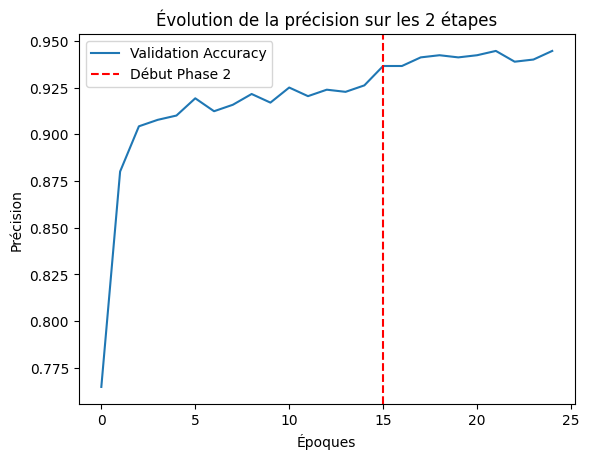

In [10]:
# Visualisation combinée
plt.plot(acc1 + acc2, label='Validation Accuracy')
plt.axvline(x=config['phase1']['epochs'], color='r', linestyle='--', label='Début Phase 2')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.legend()
plt.title('Évolution de la précision sur les 2 étapes')
plt.show()

In [11]:
def evaluate_model(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []

    # On s'assure que le modèle est sur le bon device
    model = model.to(device)

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device) # Important pour la comparaison si besoin

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

Génération du rapport d'évaluation...
Accuracy Globale: 0.9446

Rapport de Classification (Complet) :
                 precision    recall  f1-score   support

          Faces       0.98      1.00      0.99        41
     Faces_easy       1.00      0.98      0.99        44
       Leopards       1.00      1.00      1.00        25
     Motorbikes       0.99      1.00      0.99        66
      accordion       1.00      1.00      1.00         2
      airplanes       0.97      1.00      0.98        91
         anchor       1.00      0.33      0.50         6
            ant       0.83      0.83      0.83         6
         barrel       1.00      1.00      1.00         7
           bass       0.80      1.00      0.89         4
         beaver       0.50      1.00      0.67         1
      binocular       0.83      1.00      0.91         5
         bonsai       0.94      1.00      0.97        15
          brain       0.87      1.00      0.93        13
   brontosaurus       1.00      0.75      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

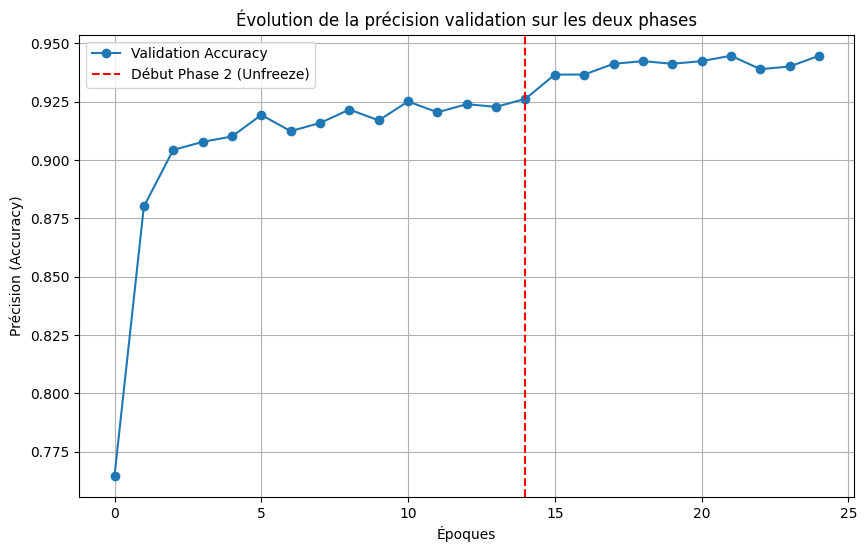

In [16]:
class_names = full_dataset.categories
# 1. Récupération des prédictions (inchangé)
print("Génération du rapport d'évaluation...")
y_true, y_pred = evaluate_model(model, dataloaders['val'])

# 2. Affichage des métriques textuelles
print(f"Accuracy Globale: {accuracy_score(y_true, y_pred):.4f}")
print("\nRapport de Classification (Complet) :")

# --- CORRECTION ICI ---
# On génère une liste d'indices de 0 à N-1 (ex: 0 à 100)
all_labels = list(range(len(class_names)))

# On passe explicitement 'labels=all_labels' pour forcer le mapping correct
# Index 0 -> Nom 0, Index 1 -> Nom 1, etc.
print(classification_report(y_true, y_pred,
                            target_names=class_names,
                            labels=all_labels))
# ----------------------

# 3. Visualisation (inchangé)
total_acc_history = acc1 + acc2

plt.figure(figsize=(10, 6))
plt.plot(total_acc_history, label='Validation Accuracy', marker='o')

split_epoch = len(acc1) - 1
plt.axvline(x=split_epoch, color='r', linestyle='--', label='Début Phase 2 (Unfreeze)')

plt.xlabel('Époques')
plt.ylabel('Précision (Accuracy)')
plt.title('Évolution de la précision validation sur les deux phases')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
def generate_rich_evaluation(model, dataloader, class_names, output_dir="outputs"):
    """
    Génère un rapport d'évaluation complet inspiré de evaluate.py :
    - JSON global
    - CSV par classe
    - Matrice de confusion (Image)
    - Leaderboard des performances (Image)
    """

    # Création du dossier de sortie
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    print("1. Calcul des prédictions...")
    # Réutilisation de votre logique d'évaluation existante
    model.eval()
    model = model.to(device)

    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    # Conversion en numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("2. Génération des rapports statistiques...")

    # --- A. Classification Report (Metrics) ---
    # Note : On inclut labels=... pour éviter l'erreur si certaines classes sont absentes du val set
    all_labels = list(range(len(class_names)))

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        labels=all_labels,
        output_dict=True,
        zero_division=0
    )

    # Création du DataFrame par classe
    # On filtre pour ne garder que les classes (on exclut accuracy, macro avg, etc. pour le CSV)
    per_class_df = pd.DataFrame(report_dict).transpose()
    per_class_df_only_classes = per_class_df.loc[class_names]

    # Sauvegarde CSV
    csv_path = out_path / "per_class_metrics.csv"
    per_class_df_only_classes.to_csv(csv_path, float_format="%.4f")

    # Sauvegarde JSON Global
    macro_avg = report_dict["macro avg"]
    weighted_avg = report_dict["weighted avg"]

    stats = {
        "val_acc": report_dict["accuracy"],
        "macro_precision": macro_avg["precision"],
        "macro_recall": macro_avg["recall"],
        "macro_f1": macro_avg["f1-score"],
        "weighted_precision": weighted_avg["precision"],
        "weighted_recall": weighted_avg["recall"],
        "weighted_f1": weighted_avg["f1-score"],
        "num_samples": int(len(y_true))
    }

    with open(out_path / "eval.json", "w") as f:
        json.dump(stats, f, indent=2)

    print("3. Génération des visualisations (Images)...")
    sns.set_theme(style="whitegrid")

    # --- B. Matrice de Confusion ---
    cm = confusion_matrix(y_true, y_pred, labels=all_labels)

    # Pour Caltech101 (101 classes), la matrice est géante.
    # On ajuste la taille de la figure dynamiquement.
    figsize_cm = max(10, len(class_names) * 0.3)
    fig, ax = plt.subplots(figsize=(figsize_cm, figsize_cm))

    sns.heatmap(
        cm,
        annot=True if len(class_names) < 30 else False, # On enlève les chiffres si trop de classes pour lisibilité
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"shrink": 0.75},
        ax=ax,
        square=True
    )
    ax.set_title("Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    fig.tight_layout()
    fig.savefig(out_path / "confusion_matrix.png", dpi=200)
    plt.close(fig)

    # --- C. Leaderboard (Barplot Precision/Recall/F1) ---
    # Préparation des données pour Seaborn (Melt)
    leaderboard_df = (
        per_class_df_only_classes[["precision", "recall", "f1-score"]]
        .reset_index()
        .rename(columns={"index": "class"})
        .melt(id_vars="class", var_name="metric", value_name="score")
    )

    # Hauteur dynamique selon le nombre de classes pour que tout soit lisible
    # Caltech101 a besoin de beaucoup de hauteur !
    height = max(5, len(class_names) * 0.3)

    fig, ax = plt.subplots(figsize=(10, height))
    sns.barplot(
        data=leaderboard_df,
        x="score",
        y="class",
        hue="metric",
        palette="viridis",
        ax=ax,
        orient="h"
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score")
    ax.set_ylabel("Class")
    ax.set_title("Per-class Metrics Leaderboard")
    ax.legend(title="Metric", loc="lower right")

    # On inverse l'axe Y pour avoir l'ordre alphabétique de haut en bas
    # (ou on pourrait trier par score F1 pour voir les meilleures classes en premier)
    # ax.invert_yaxis()

    fig.tight_layout()
    fig.savefig(out_path / "leaderboard.png", dpi=200)
    plt.close(fig)

    print(f"✅ Terminé ! Résultats sauvegardés dans : {out_path.absolute()}")
    print(f"  - eval.json")
    print(f"  - per_class_metrics.csv")
    print(f"  - confusion_matrix.png")
    print(f"  - leaderboard.png")

# --- Lancement de l'évaluation ---
generate_rich_evaluation(model, dataloaders['val'], full_dataset.categories, output_dir="outputs")

1. Calcul des prédictions...
2. Génération des rapports statistiques...
3. Génération des visualisations (Images)...
✅ Terminé ! Résultats sauvegardés dans : /content/dl_project/starters/cv-project-starter/cv-project/outputs
  - eval.json
  - per_class_metrics.csv
  - confusion_matrix.png
  - leaderboard.png


📊 MÉTRIQUES GLOBALES


,val_acc,macro_f1,weighted_f1,num_samples
0,0.9446,0.8920,0.9444,867.0000



🏆 TOP & FLOP CLASSES (Basé sur F1-Score)
✅ Les 5 Meilleures classes :


,precision,recall,f1-score,support
Leopards,1.000000,1.000000,1.000000,25.000000
accordion,1.000000,1.000000,1.000000,2.000000
dollar_bill,1.000000,1.000000,1.000000,2.000000
car_side,1.000000,1.000000,1.000000,11.000000
barrel,1.000000,1.000000,1.000000,7.000000


❌ Les 5 Moins bonnes classes :


,precision,recall,f1-score,support
lobster,1.000000,0.400000,0.571400,5.000000
anchor,1.000000,0.333300,0.500000,6.000000
gerenuk,0.000000,0.000000,0.000000,0.000000
mandolin,0.000000,0.000000,0.000000,1.000000
wrench,0.000000,0.000000,0.000000,0.000000



📈 VISUALISATIONS GÉNÉRÉES


### 1. Leaderboard des classes

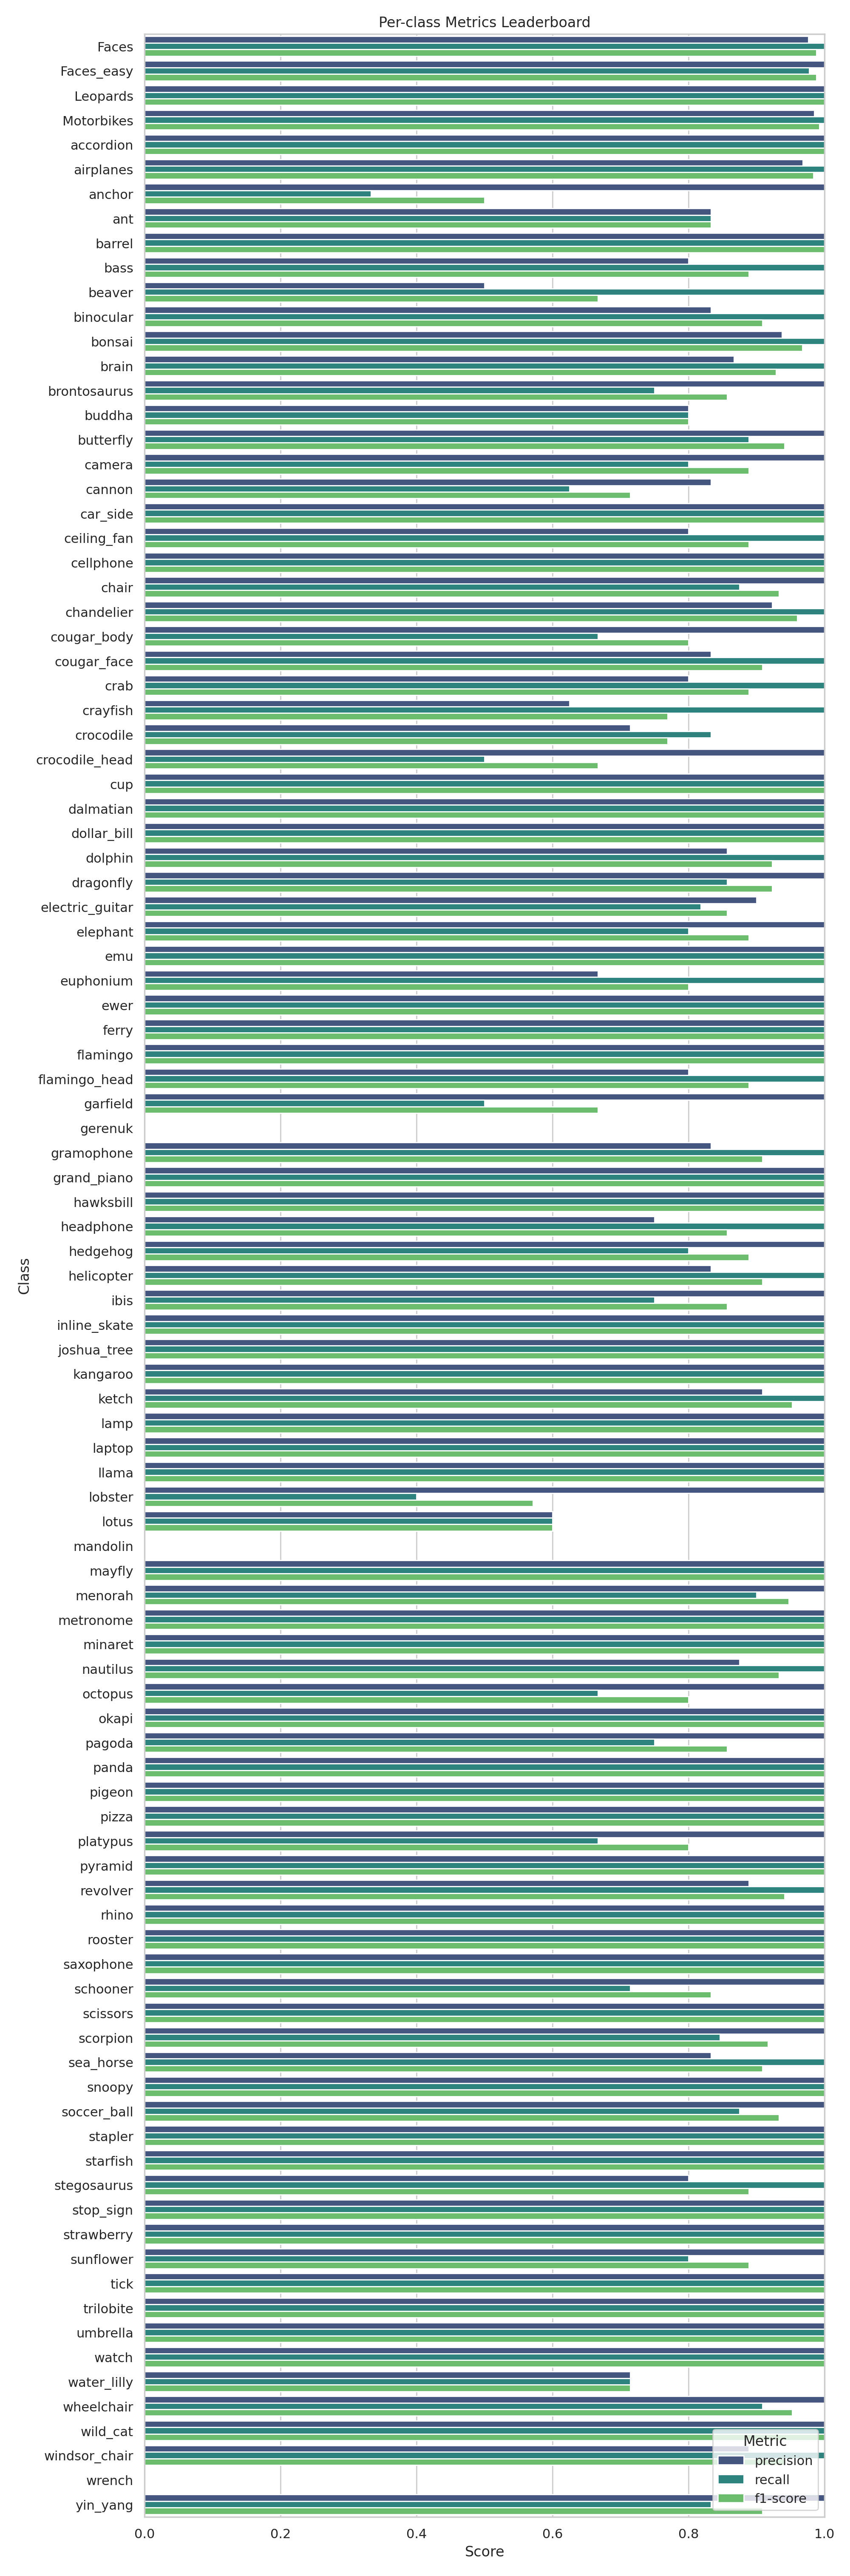

### 2. Matrice de Confusion

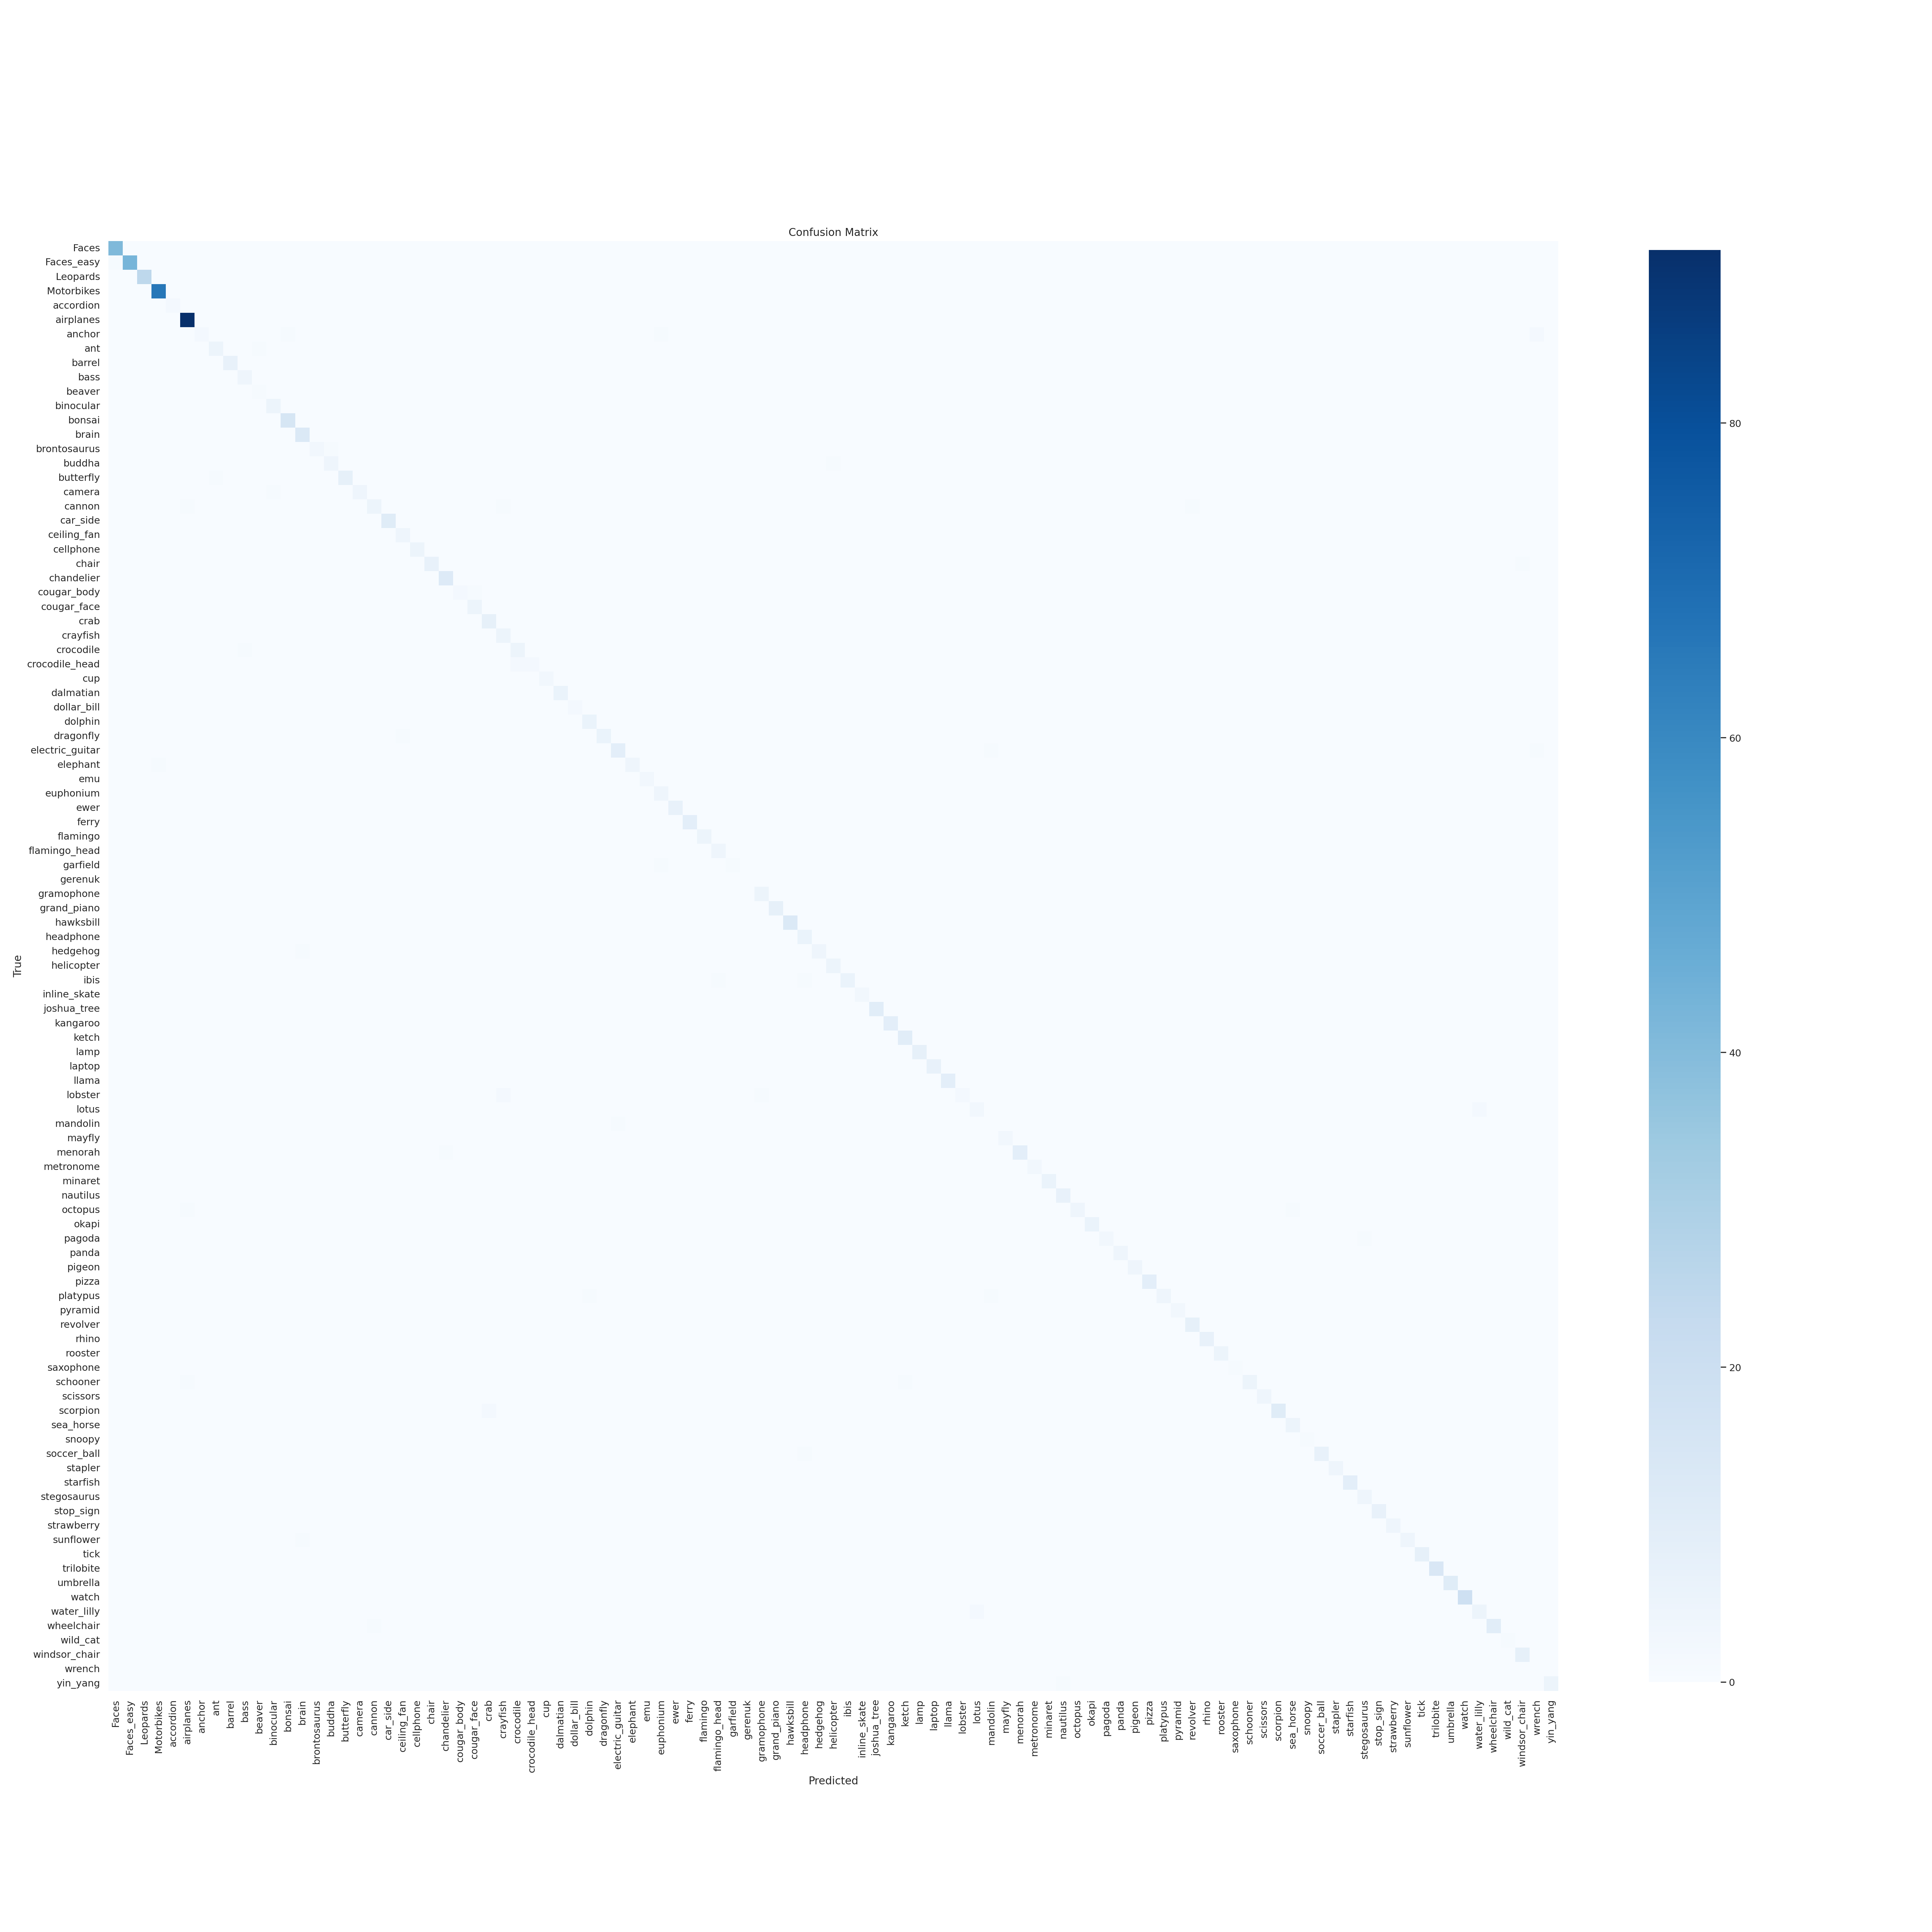

In [18]:
output_dir = "outputs"

# --- 1. Affichage des Métriques Globales (JSON) ---
print("📊 MÉTRIQUES GLOBALES")
print("="*30)
with open(f"{output_dir}/eval.json", "r") as f:
    metrics = json.load(f)

# On affiche sous forme de petit tableau propre
global_df = pd.DataFrame([metrics], columns=["val_acc", "macro_f1", "weighted_f1", "num_samples"])
display(global_df.style.format("{:.4f}"))

# --- 2. Analyse par Classe (CSV) ---
print("\n🏆 TOP & FLOP CLASSES (Basé sur F1-Score)")
print("="*30)
df_classes = pd.read_csv(f"{output_dir}/per_class_metrics.csv", index_col=0)

# Tri par F1-score décroissant
df_sorted = df_classes.sort_values(by="f1-score", ascending=False)

print("✅ Les 5 Meilleures classes :")
display(df_sorted.head(5).style.background_gradient(cmap="Greens", subset=["f1-score"]))

print("❌ Les 5 Moins bonnes classes :")
display(df_sorted.tail(5).style.background_gradient(cmap="Reds_r", subset=["f1-score"]))

# --- 3. Visualisations (Images) ---
print("\n📈 VISUALISATIONS GÉNÉRÉES")
print("="*30)

display(Markdown("### 1. Leaderboard des classes"))
display(Image(filename=f"{output_dir}/leaderboard.png", width=800))

display(Markdown("### 2. Matrice de Confusion"))
display(Image(filename=f"{output_dir}/confusion_matrix.png", width=600))